# 03d — ML energy resolution via a Crystal-Ball density network

[`03_ml_training_and_eval.ipynb`](03_ml_training_and_eval.ipynb) learns three **quantiles**
of the response and reads the resolution off a Neyman band;
[`03c_conventional_resolution.ipynb`](03c_conventional_resolution.ipynb) instead fits a
**Crystal Ball** to fixed-energy runs and inverts the calibration to quote σ_E/E. This
notebook unifies the two: the network outputs the **parameters of a Crystal Ball**
(μ, σ, α, n) as a smooth function of energy, trained by maximum likelihood on the raw
readouts. It is literally "a Crystal-Ball fit done inside the network", learned from the
whole spectrum in one shot.

Because it hands us the full Crystal Ball at every energy, we can read off **two** widths and
turn each into an energy resolution the **same way 03c does** — by inverting the learned
calibration μ(E):

- its **Gaussian-core** σ, inverted, reproduces 03c's core σ_E/E (directly comparable), and
- the *same* Crystal Ball's tail-inclusive **effective** width, inverted, is comparable to the
  raw data's central-68 and to nb03's band.

That resolves the puzzle 03c surfaced: the DECAL response is a narrow core plus a growing
low-side leakage tail, so the "core" (03c) and "effective" (data / nb03) resolutions
legitimately diverge at high energy. The CB-density net reports **both**, from one training.

It is *not* free of an inversion — like 03c it must invert a calibration to get an energy
resolution — but that calibration is now a **smooth learned μ(E)** rather than a handful of
fixed-energy points, and the net separates the core from the effective width, which neither
of the other two notebooks does on its own. (This complements nb03 rather than correcting it:
nb03's linearity panel is a labelled self-consistency check and nb03 also ships a held-out
closure test — see §8. The CB net simply adds the core-vs-effective split.)

**Kernel**: `Key4hep + GPU`.
**Input**: the spectrum extraction `models/decal_extracted_data_<particle>.npz` (as nb03),
plus the fixed-energy `models/mono_<particle>/` runs (as 03c) for the head-to-head overlay.

## 0. Choose your particle

The **one knob**. Everything downstream — which spectrum file and which fixed-energy
directory are read — derives from `PARTICLE`, exactly as in nb03 and 03c. Photons are the
default; pions strain the Crystal-Ball assumption (see §9).

In [1]:
PARTICLE = "gamma"                 # "gamma" or "pi+"
PART_TAG = "gamma" if PARTICLE == "gamma" else "piplus"
print(f"PARTICLE = {PARTICLE!r}  ->  spectrum models/decal_extracted_data_{PART_TAG}.npz, "
      f"fixed-energy models/mono_{PART_TAG}/")

PARTICLE = 'gamma'  ->  spectrum models/decal_extracted_data_gamma.npz, fixed-energy models/mono_gamma/


## 1. Verify the kernel + GPU

In [2]:
import torch, sys
print(f"torch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no CUDA device -> training will run on CPU (much slower). "
          "Select the 'Key4hep + GPU' kernel on a GPU node.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

torch version: 2.5.1+cu121
cuda available: True
GPU: NVIDIA A100 80GB PCIe MIG 2g.20gb

Using device: cuda


## 2. Load the extracted spectrum

Identical to nb03 — the same per-particle `decal_extracted_data_<tag>.npz`. Only the imported
model changes: `cbnet` (the Crystal-Ball density network) instead of `quantilenet`. We also
import the **shared** conventional fitter + calibration inversion from
`analysis/decal_cbfit.py`, so the "conventional (03c)" curves overlaid later are produced by
*exactly* 03c's code, not a re-implementation.

In [3]:
import os, numpy as np
def _calomaps_home():
    h = os.environ.get("CALOMAPS_HOME")
    if h and os.path.isdir(os.path.join(h, "geometry")):
        return h
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.isdir(os.path.join(p, "geometry")) and os.path.isdir(os.path.join(p, "sim")):
            return p
        p = os.path.dirname(p)
    return os.path.expanduser("~/CALOMAPS")
CALOMAPS_HOME = _calomaps_home()
sys.path.insert(0, os.path.join(CALOMAPS_HOME, "analysis"))
from cbnet import (CBNet, cb_nll, save_ensemble, load_ensemble,
                   train_one_ensemble, cb_params_over_grid, resolution_over_grid)
from decal_cbfit import fit_response, build_calibration

npz_path = os.path.join(CALOMAPS_HOME, "models", f"decal_extracted_data_{PART_TAG}.npz")
data = np.load(npz_path)
all_truth   = data["all_truth"]
all_visible = data["all_visible"]; all_mip = data["all_mip"]
all_hits    = data["all_hits"];    all_cluster = data["all_cluster"]
print(f"loaded {len(all_truth)} events from {npz_path}")
valid = (all_hits > 0) & (all_truth > 0) & (all_visible > 0) & (all_mip > 0) & (all_cluster > 0)
x_train = all_truth[valid]
print(f"valid events for training: {valid.sum()}   E range [{x_train.min():.0f}, {x_train.max():.0f}] GeV")

loaded 17780 events from /nashome/m/murtazas/CALOMAPS/models/decal_extracted_data_gamma.npz
valid events for training: 17780   E range [5, 400] GeV


## 3. Train (or load) the four Crystal-Ball density ensembles

Structurally identical to nb03's training cell — `train_one_ensemble` has the *same
signature* (that is the whole point of keeping the delta small). Each ensemble member is a
`CBNet` trained by NLL of the Crystal Ball, on a different 80/20 split; averaging their
predicted CB shapes gives the surrogate density. ~a few minutes on the A100. Set
`CB_RETRAIN=0` in the environment to reuse ensembles already in `models/saved_cbnet_gpu_<tag>/`
(re-run the plots without retraining).

In [4]:
RETRAIN = os.environ.get("CB_RETRAIN", "1") == "1"   # 1 = train fresh (default); 0 = reuse saved
ENSEMBLE_DIR = os.path.join(CALOMAPS_HOME, "models", f"saved_cbnet_gpu_{PART_TAG}")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

_specs = [("True Analog", all_visible, 1000, "cb_analog.pth"),
          ("MIP counting", all_mip,    2000, "cb_mip.pth"),
          ("Raw Hits",     all_hits,   3000, "cb_hits.pth"),
          ("Naive 2D Clustering", all_cluster, 4000, "cb_cluster.pth")]
have = all(os.path.exists(os.path.join(ENSEMBLE_DIR, f)) for *_, f in _specs)
_NM = int(os.environ.get("CB_NMODELS", "20"))          # env knobs for a quick smoke run
_EP = int(os.environ.get("CB_EPOCHS", "5000"))
if RETRAIN or not have:
    for label, y_arr, seed, fname in _specs:
        ens, xmax, ymax = train_one_ensemble(all_truth[valid], y_arr[valid], device,
                                              name=label, num_models=_NM, epochs=_EP, seed_base=seed)
        save_ensemble(ens, xmax, ymax, os.path.join(ENSEMBLE_DIR, fname))
else:
    print(f"Loading existing CB-net ensembles from {ENSEMBLE_DIR}")

ens_a, xa, ya = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_analog.pth"),  device)
ens_m, xm, ym = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_mip.pth"),     device)
ens_h, xh, yh = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_hits.pth"),    device)
ens_c, xc, yc = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_cluster.pth"), device)
ENS = {"True Analog": (ens_a, xa, ya), "MIP counting": (ens_m, xm, ym),
       "Raw Hits": (ens_h, xh, yh), "Naive 2D Clustering": (ens_c, xc, yc)}
KEYCOL = {"True Analog":"royalblue","MIP counting":"forestgreen","Raw Hits":"crimson","Naive 2D Clustering":"darkorchid"}
KEYNPZ = {"True Analog":"all_visible","MIP counting":"all_mip","Raw Hits":"all_hits","Naive 2D Clustering":"all_cluster"}
print(f"ready: 4 CB-net ensembles, {len(ens_a)} models each, on {device}")

=== CB-net ensemble: True Analog  (N=17780, x_max=400, y_frac_max=0.0202) ===


  model  1/20  best_nll=-1.4950  epochs= 2400  (10.1s)


  model  2/20  best_nll=-1.4977  epochs= 4487  (17.9s)


  model  3/20  best_nll=-1.5028  epochs= 2155  (7.8s)


  model  4/20  best_nll=-1.4935  epochs= 2320  (9.5s)


...

  model 16/20  best_nll=-1.9427  epochs= 1018  (3.9s)


  model 17/20  best_nll=-1.9124  epochs=  913  (3.4s)


  model 18/20  best_nll=-1.9444  epochs= 1519  (5.8s)


  model 19/20  best_nll=-1.9366  epochs= 1045  (4.0s)


  model 20/20  best_nll=-1.9640  epochs= 3777  (14.5s)
  ensemble total: 228.0s
ready: 4 CB-net ensembles, 20 models each, on cuda


## 4. The raw data the density net learns from

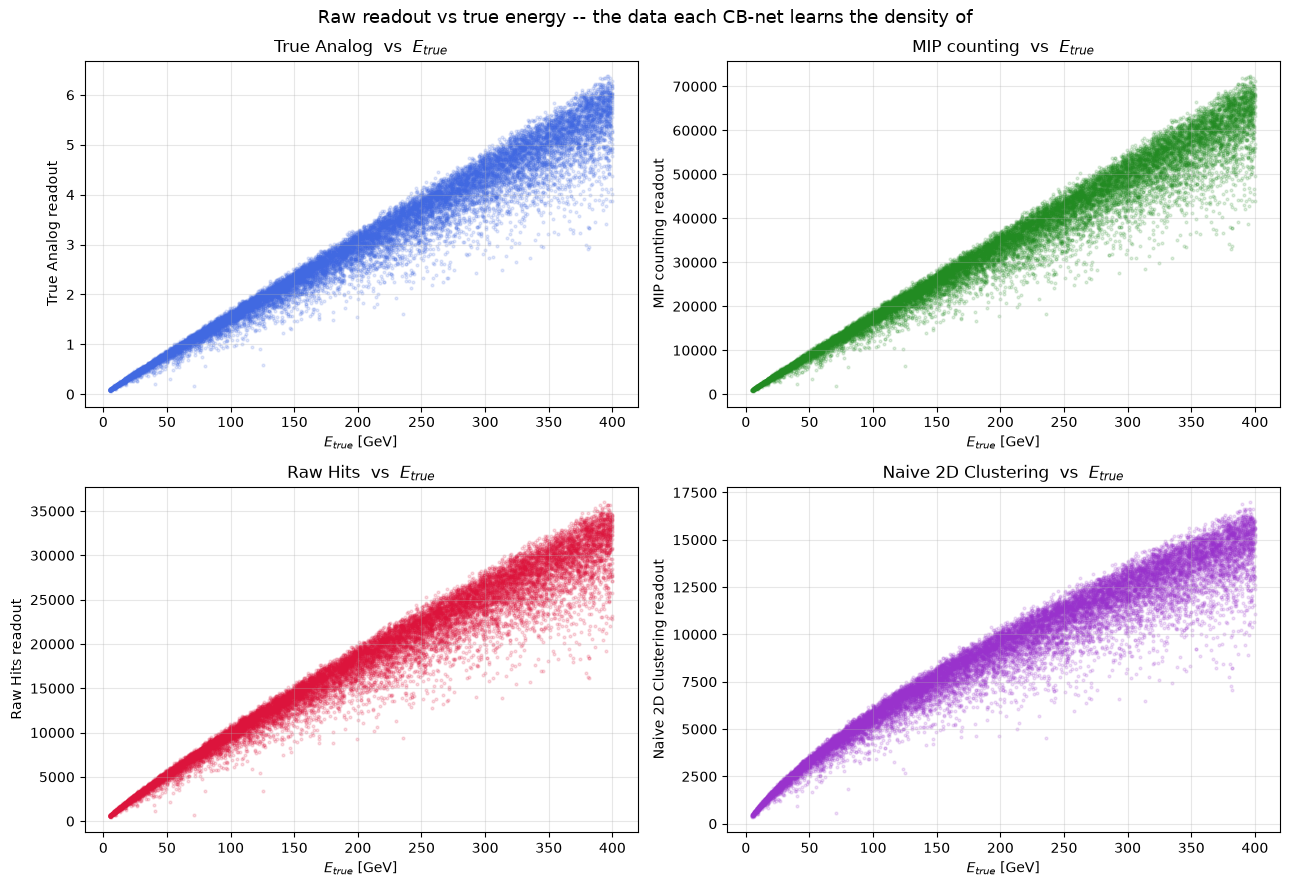

In [5]:
import matplotlib.pyplot as plt
readouts = {"True Analog": all_visible[valid], "MIP counting": all_mip[valid],
            "Raw Hits": all_hits[valid], "Naive 2D Clustering": all_cluster[valid]}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ax.scatter(x_train, y, s=4, alpha=0.15, color=KEYCOL[name])
    ax.set_title(f"{name}  vs  $E_{{true}}$"); ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout"); ax.grid(True, alpha=0.3)
fig.suptitle("Raw readout vs true energy -- the data each CB-net learns the density of", fontsize=13)
plt.tight_layout(); plt.show()

## 5. Does the fit describe the data? — data vs conventional fit vs the network

The key sanity check, at a few **fixed energies** spanning the spectrum (using the dedicated
`mono_<particle>` runs, so the response is clean, not spectrum-smeared). Each panel shows the
actual response (histogram), the **conventional Crystal-Ball fit** (03c's `fit_response` —
dashed black), and the **CB-net's predicted Crystal Ball** (solid colour). If the network is
doing its job, its curve tracks the data — and the conventional fit — reproducing the sharp
core **and** the low-side leakage tail that a single Gaussian cannot. This is the falsifiable
check on the density; everything downstream (the resolutions) is a summary of these shapes.
Everything is in fractional-response ($y/E_{\rm true}$) units so the energies are directly
comparable. (Analog shown; set `READOUT` for the digital readouts.)

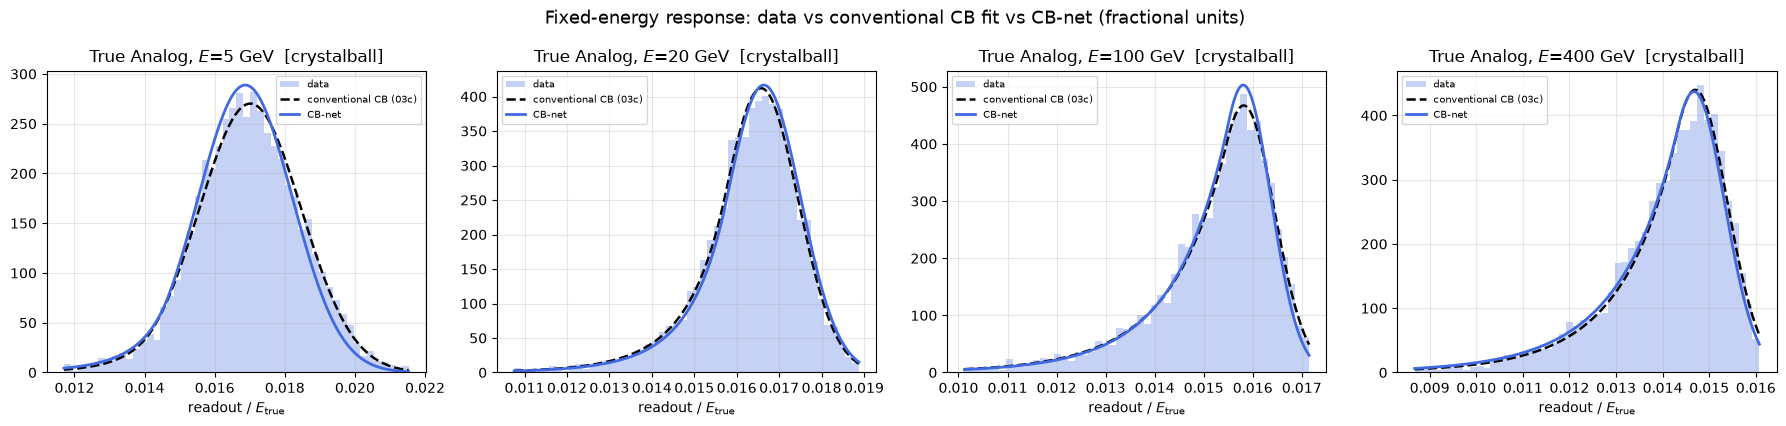

In [6]:
from scipy.stats import crystalball, norm

def predicted_cb(name, E):
    """CB-net predicted Crystal Ball (mu, sigma, alpha, n) at energy E, fractional units."""
    ens, xmax, ymax = ENS[name]
    p = cb_params_over_grid(ens, xmax, ymax, device, np.array([float(E)]))
    return p["mu"][0], p["sigma"][0], p["alpha"][0], p["n"][0]

MONO_DIR = os.path.join(CALOMAPS_HOME, "models", f"mono_{PART_TAG}")
READOUT = "True Analog"; RKEY = KEYNPZ[READOUT]
SHOW_E = [5, 20, 100, 400]              # fixed points across the spectrum
fig, axes = plt.subplots(1, len(SHOW_E), figsize=(18, 4.3))
for ax, E in zip(axes, SHOW_E):
    f = os.path.join(MONO_DIR, f"decal_mono_{PART_TAG}_E{E:04d}GeV.npz")
    if not os.path.exists(f):
        ax.set_title(f"{E} GeV: no mono run"); ax.axis("off"); continue
    dd = np.load(f); Etrue = float(dd["E_nominal"]) if "E_nominal" in dd.files else float(E)
    r = dd[RKEY].astype(float) / Etrue          # fractional response
    lo, hi = np.percentile(r, [0.3, 99.7]); xx = np.linspace(lo, hi, 400)
    ax.hist(r, bins=50, range=(lo, hi), density=True, color=KEYCOL[READOUT], alpha=0.30, label="data")
    # conventional fit via the SHARED 03c fitter (never raises; degrades CB->Gaussian->RMS)
    cf = fit_response(r)
    if cf["model"] == "crystalball":
        ax.plot(xx, crystalball.pdf(xx, cf["beta"], cf["m"], loc=cf["mu"], scale=cf["sigma"]),
                "--", color="k", lw=1.8, label="conventional CB (03c)")
    elif cf["model"] == "gaussian":
        ax.plot(xx, norm.pdf(xx, loc=cf["mu"], scale=cf["sigma"]),
                "--", color="k", lw=1.8, label="conventional Gaussian (03c)")
    nmu, nsg, nal, nnn = predicted_cb(READOUT, E)
    ax.plot(xx, crystalball.pdf(xx, nal, nnn, loc=nmu, scale=nsg), "-", color=KEYCOL[READOUT], lw=2, label="CB-net")
    ax.set_title(f"{READOUT}, $E$={E} GeV  [{cf['model']}]"); ax.set_xlabel(r"readout / $E_{\rm true}$")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle("Fixed-energy response: data vs conventional CB fit vs CB-net (fractional units)", fontsize=13)
plt.tight_layout(); plt.show()

## 6. From the density to the resolution — **two** widths, via the calibration inversion

Because the network hands us the full Crystal Ball at each energy, the two widths come
straight from its parameters — and each is turned into an **energy** resolution by inverting
the learned calibration μ(E), the **same move 03c makes** (a readout width is not a resolution
until you invert the response; essential for the saturating digital readouts):

- **core** $\;\sigma_E/E$ — from the Gaussian-core width (identical definition to 03c's core),
- **effective** $\;\sigma_E/E$ — from the tail-inclusive $(P_{84}-P_{16})$ of the *same* CB.

Unlike nb03 there is no per-event root-find and no ≡1 self-consistency step; the inversion is
of a single smooth curve. We evaluate over the **training range only** (the spectrum range
printed in §2, log-spaced) — the net has no data outside it and would extrapolate blindly
(see §9).

In [7]:
E_LO, E_HI = float(x_train.min()), float(x_train.max())   # the actual training range (printed in §2)
E_GRID = np.logspace(np.log10(E_LO), np.log10(E_HI), 120)   # log-spaced over that range
res = {}
for name, (ens, xmax, ymax) in ENS.items():
    cb, core, eff = resolution_over_grid(ens, xmax, ymax, device, E_GRID)
    res[name] = {"cb": cb, "core": core, "eff": eff}
print("extracted core and effective sigma_E/E for 4 readouts over 5-400 GeV (energy-domain, inverted)")

extracted core and effective sigma_E/E for 4 readouts over 5-400 GeV (energy-domain, inverted)


## 7. Head-to-head: ML density net vs the conventional fixed-energy fit

The direct comparison, both sides in **energy** units (σ_E/E), both inverted through a
calibration. **Lines** = the CB-density net, trained on the single spectrum. If you generated
the fixed-energy `mono_<particle>` runs (§0), **points** = the conventional method (03c): a
Crystal-Ball fit to each run, its per-readout calibration built and inverted exactly as in 03c
(circles = the inverted Gaussian-**core** σ_E/E; squares = the inverted data central-68,
$(P_{84}-P_{16})$); without those runs the panel shows the CB-net lines alone. If the ML density
net is right, the lines pass through the points — core-on-core (left) and effective-on-effective
(right) — *without needing the fixed-energy runs at all*. The shaded band marks energies **below
the training range** (its low edge printed in §2): any conventional points there (from dedicated
low-energy beams) show the steep stochastic rise the net cannot see. Read the **high-energy
endpoint** with the same caution — it is the lowest-statistics, unconstrained boundary of the
spectrum, so those values are extrapolations (see §9).

conventional fits by model: {'crystalball': 36, 'gaussian': 0, 'rms': 0, 'none': 0}   (gaussian/rms = graceful-degrade fallbacks, shown so a fallback can't silently masquerade as a CB result)


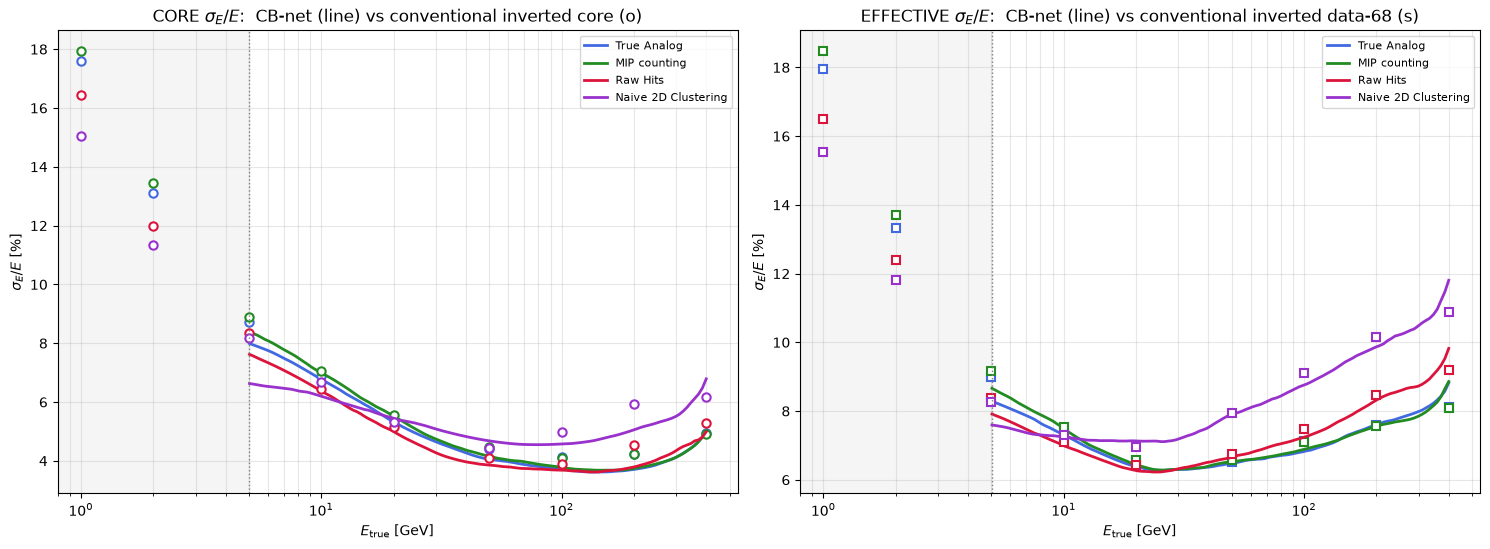

In [8]:
import glob
mono_files = sorted(glob.glob(os.path.join(MONO_DIR, "*.npz")))
# pass 1: fit every (readout, energy) with the SHARED 03c fitter; record mu, sigma, data P16/P84
raw = {name: {"E": [], "mu": [], "sig": [], "p16": [], "p84": []} for name in ENS}
_models = {"crystalball": 0, "gaussian": 0, "rms": 0, "none": 0}
for f in mono_files:
    d = np.load(f); E = float(d["E_nominal"]) if "E_nominal" in d.files else float(np.median(d["all_truth"]))
    for name in ENS:
        v = np.asarray(d[KEYNPZ[name]], float); v = v[np.isfinite(v)]
        r = fit_response(v); _models[r["model"]] = _models.get(r["model"], 0) + 1
        if not (r["ok"] and r["mu"] > 0):
            continue
        p16, p84 = np.percentile(v, [15.87, 84.13])
        raw[name]["E"].append(E); raw[name]["mu"].append(r["mu"]); raw[name]["sig"].append(r["sigma"])
        raw[name]["p16"].append(p16); raw[name]["p84"].append(p84)
print(f"conventional fits by model: {_models}   (gaussian/rms = graceful-degrade fallbacks, shown so a "
      f"fallback can't silently masquerade as a CB result)")

# pass 2: per readout, build the calibration from its own mu(E) and INVERT both bands to sigma_E/E
conv = {}
for name in ENS:
    E = np.array(raw[name]["E"]); mu = np.array(raw[name]["mu"]); sig = np.array(raw[name]["sig"])
    p16 = np.array(raw[name]["p16"]); p84 = np.array(raw[name]["p84"])
    if np.unique(E).size < 2:
        conv[name] = None; continue
    _, ginv, _, _ = build_calibration(E, mu)
    core = (ginv(mu + sig) - ginv(np.maximum(mu - sig, 1e-9))) / (2.0 * E)          # inverted core (== 03c)
    eff  = (ginv(np.maximum(p84, 1e-9)) - ginv(np.maximum(p16, 1e-9))) / (2.0 * E)  # inverted data 68% (~ nb03)
    conv[name] = {"E": E, "core": core * 100, "eff": eff * 100}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for name in ENS:
    c = KEYCOL[name]
    axes[0].plot(E_GRID, res[name]["core"]*100, "-", color=c, lw=2, label=name)
    axes[1].plot(E_GRID, res[name]["eff"]*100,  "-", color=c, lw=2, label=name)
    if conv.get(name) is not None:
        axes[0].plot(conv[name]["E"], conv[name]["core"], "o", color=c, ms=6, mfc="white", mew=1.5)
        axes[1].plot(conv[name]["E"], conv[name]["eff"],  "s", color=c, ms=6, mfc="white", mew=1.5)
axes[0].set_title(r"CORE $\sigma_E/E$:  CB-net (line) vs conventional inverted core (o)")
axes[1].set_title(r"EFFECTIVE $\sigma_E/E$:  CB-net (line) vs conventional inverted data-68 (s)")
E_LO = float(E_GRID.min())                              # training-range low edge (from §6)
_lefts = [E_LO] + [float(np.min(c["E"])) for c in conv.values() if c is not None]
_left = max(0.5, min(_lefts) * 0.8)                     # show any sub-range mono points too
for ax in axes:
    ax.set_xscale("log"); ax.set_xlim(left=_left)
    ax.axvspan(_left, E_LO, color="gray", alpha=0.08)   # below the training range: net extrapolates
    ax.axvline(E_LO, color="gray", ls=":", lw=1)
    ax.set_xlabel(r"$E_{\rm true}$ [GeV]")
    ax.set_ylabel(r"$\sigma_E/E$ [%]"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
if not mono_files:
    fig.suptitle("(no models/mono_<tag> runs found -> conventional points skipped; showing CB-net only)", fontsize=10)
plt.tight_layout(); plt.show()

## 8. The learned response / calibration

The network's learned **response** μ(E) — the Crystal-Ball **peak** (most-probable readout,
the CB `loc`, *not* the mean: the low-side leakage tail pulls the true mean below the peak).
This is the very curve §6–§7 inverted. Straight on log-log = linear; the digital readouts bend
over as they saturate — the root cause of the core/effective divergence.

This is a genuine, falsifiable **response** curve — though the sharpest data check is §5 (the fit
tracking the histogram), not this summary. It is a different object from nb03's linearity panel
($E_{\rm reco}/E_{\rm true}\equiv 1$), a *self-consistency* check of the inversion, and from
nb03's held-out closure test ($\langle E_{\rm reco}/E_{\rm true}\rangle$ on events no member
trained on): the three simply check different things — a response shape, an inversion's
self-consistency, and out-of-sample calibration.

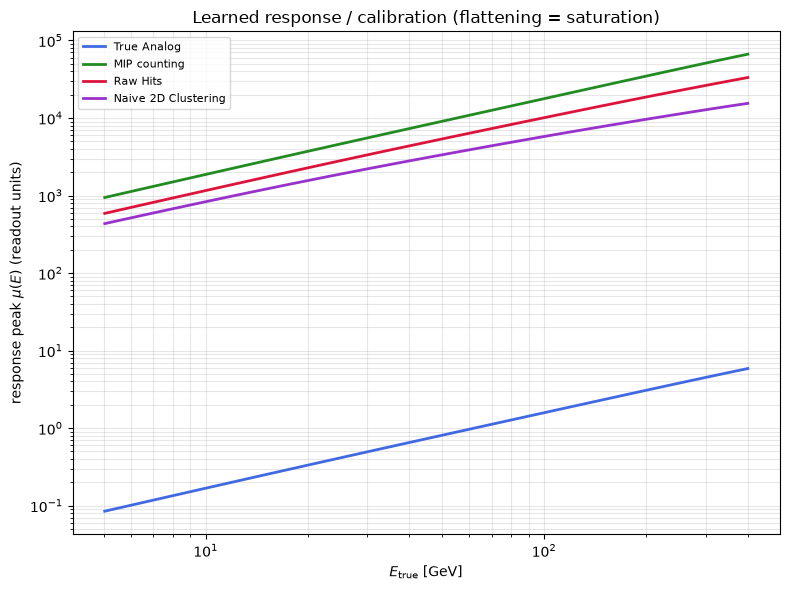

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in ENS:
    ax.plot(E_GRID, res[name]["cb"]["mu"] * E_GRID, "-", color=KEYCOL[name], lw=2, label=name)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$E_{\rm true}$ [GeV]"); ax.set_ylabel(r"response peak $\mu(E)$ (readout units)")
ax.set_title("Learned response / calibration (flattening = saturation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 9. What this reconciles — and its limits

**One model, both numbers.** From a single spectrum training the CB-density net reproduces the
conventional fixed-energy result (inverted **core** σ_E/E, the circles) *and* the tail-inclusive
data width (inverted **effective** σ_E/E, the squares) — the two quantities 03c and nb03 each
reported in isolation. The gap between the core and effective curves **is** the growing low-side
leakage tail; both are real, and quoting only the core (03c's headline) is optimistic while a
band alone (nb03) doesn't separate which is which.

**Versus the other two notebooks:**
- vs **nb03 (quantiles + Neyman band):** same spectrum input and GPU cost. The CB net models the
  density directly, so it separates core from effective and needs no per-event root-find — though
  it still inverts a calibration, just a smooth learned one. nb03's $E_{\rm reco}/E_{\rm true}\equiv 1$
  panel is a labelled self-consistency check and nb03 also carries a held-out closure test; the CB
  net's distinct contribution is the core/effective split and the directly falsifiable density (§5).
- vs **03c (conventional fixed-energy fits):** the ML net delivers the whole training-range curve
  from one spectrum, no dedicated fixed-energy runs. 03c remains the transparent ground truth (and
  the points here confirm the net against it).

**Limits to keep honest:**
- **Training range (low end).** The net is trusted only within the spectrum's range (printed in §2);
  below its low edge (shaded in §7) it extrapolates and *underestimates* — the steep stochastic rise
  the low-energy mono points show is invisible to it. The conventional method can measure any energy
  you simulate.
- **High-energy edge / low stats.** A continuous spectrum has its *fewest* events at the top of its
  range, an unconstrained boundary, so the CB params — the tail especially — are least determined
  exactly where core and effective diverge most. Read the endpoint values as boundary extrapolations,
  not precision numbers.
- **A Crystal Ball is still an assumed shape.** It fits this core+low-tail response well (§5); a
  response with a *high*-side tail (e.g. hadrons — see 03c's pion caveat) would need a different
  density, and the single-peak CB would misreport the width.

> **If this proves out** it could stand alongside — or eventually replace — nb03's quantile head:
> the diff from nb03 is only the model (`cbnet` vs `quantilenet`) and this resolution section.